# The Closing Window — data exploration

Shape-first look at the designer data. Loads the full Phase 2
collection if it exists, otherwise the pilot. Every cell is
independent enough to tweak and re-run.

Run in VS Code (interactive cells) or:
  uv run jupytext --to ipynb notebooks/explore.py && uv run jupyter lab notebooks/explore.ipynb

In [295]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = Path(__file__).resolve().parents[1] if "__file__" in dir() else Path.cwd().parents[0]
DATA = ROOT / "data"

full = DATA / "full" / "designers.parquet"
pilot = DATA / "pilot" / "designers.parquet"
df = pd.read_parquet(full if full.exists() else pilot)
anchors = pd.read_parquet(DATA / "pilot" / "anchors.parquet")

print(f"loaded {'FULL' if full.exists() else 'PILOT'}: {len(df)} designers, "
      f"{len(anchors)} anchors")
df.head(3)

loaded FULL: 3130 designers, 15 anchors


,designer_id,designer_name,permalink,username,user_id,fan_count,n_patterns,n_knitting,n_crochet,pct_free,...,cohort_year,instagram,ig_followers,website,other_sites,location,country,discovered_via_pattern,discovery_year,collected_at
0,2429,Amy O'Neill Houck,amy-oneill-houck,amyo,1988.0,402,113,36,77,0.256637,...,2007.0,http://instagram.com/alaskatarian,None,None,[facebook:http://www.facebook.com/aoh@ipsmedia...,"Cordova, Alaska",US,47775,2008,2026-08-08T01:46:04.630846+00:00
1,11633,Kimberly Turnbow,kimberly-turnbow,NaN,NaN,15,13,12,1,0.846154,...,2007.0,NaN,None,None,[],NaN,NaN,11072,2007,2026-08-08T01:46:04.633651+00:00
2,68704,YlloTyll,yllotyll,YlloTyll,3704143.0,123,104,102,2,0.009615,...,2007.0,http://instagram.com/yllotyll,None,None,[facebook:http://www.facebook.com/yllotyll],"Uppsala, Sweden",SE,79803,2008,2026-08-08T01:46:06.488005+00:00


## Setup: eras, weights, helper stats

In [296]:
ERA_BINS = [2006, 2012, 2019, 2025]
ERA_LABELS = ["2007-12 (blog)", "2013-19 (early IG)", "2020-24 (algorithm)"]
df["era"] = pd.cut(df["cohort_year"], ERA_BINS, labels=ERA_LABELS)

# institutional-route flag (becca's ruling, 2026-08-07): a pre-2007
# start is NOT evidence of the print route — many bloggers predate
# Ravelry. Institutional requires positive evidence: majority of the
# catalog in print sources. Pre-2007 + low print share = early-web
# self-publisher, i.e. the blog cohort's vanguard, kept in their
# timing-based era.
df["pre_ravelry_pub"] = pd.to_numeric(
    df["first_pub_anywhere"].str[:4], errors="coerce") < 2007
df["institutional"] = df["print_source_share"] > 0.5

# Four-cohort scheme: the print cohort is defined by ROUTE, not year —
# their cohort_year is just the Ravelry import date, so without this
# they'd be miscounted as blog-era. CAVEATS for the print cohort: only
# imported catalogs appear (someone had to care enough to catalog them),
# and their fan counts are the MODERN echo of a print-era career, not
# their own era's audience. Useful precisely as that: what does
# institutional-era reputation convert to in the attention economy?
df["cohort4"] = pd.Categorical(
    np.where(df["institutional"], "print/institutional",
             df["era"].astype(str)),
    categories=["print/institutional"] + ERA_LABELS, ordered=True)
df.groupby("cohort4", observed=True)["fan_count"].describe()

df["crochet_share"] = df["n_crochet"] / (df["n_crochet"] + df["n_knitting"])
df["fans_per_pattern"] = df["fan_count"] / df["n_patterns"]


MILESTONES = [
    (2007, "Ravelry launches"),
    (2010, "Instagram debuts"),
    (2013, "Google Reader dies"),
    (2016, "IG feed goes algorithmic"),
    (2018, "TikTok arrives (US)"),
    (2020, "pandemic + NuRav fracture"),
]


def add_milestones(ax, labels: bool = True) -> None:
    """Dashed era markers for any chart with cohort years on the x-axis."""
    ymax = ax.get_ylim()[1]
    for year, label in MILESTONES:
        ax.axvline(year, ls="--", lw=0.8, color="grey", alpha=0.6)
        if labels:
            ax.text(year, ymax * 0.98, f" {label}", rotation=90,
                    va="top", ha="left", fontsize=7, color="grey")


def gini(x) -> float | None:
    x = np.sort(np.asarray(x, dtype=float))
    x = x[~np.isnan(x)]
    n = len(x)
    if n == 0 or x.sum() == 0:
        return None
    return float((2 * np.arange(1, n + 1) - n - 1).dot(x) / (n * x.sum()))


df.groupby("era", observed=True)["fan_count"].describe()

,count,mean,std,min,25%,50%,75%,max
era,,,,,,,,
2007-12 (blog),1523.0,919.197636,3103.245953,0.0,34.0,149.0,577.5,52640.0
2013-19 (early IG),1115.0,770.468161,3209.768133,0.0,19.0,105.0,489.5,66721.0
2020-24 (algorithm),477.0,262.450734,1007.483201,0.0,8.0,31.0,122.0,11386.0


## 0b. Platform output per year (from the ID census)
Pattern IDs are sequential, so each year's ID-range width estimates
patterns created that year (including later-deleted ones). NOTE: our
designer sample CANNOT measure cohort sizes — the 50/year quota
flattens them by design. This census is the platform-level
denominator; a designer-cohort-size estimator (share of each year's
patterns that are first-year output) is a planned follow-up pass.

2009    100000
2010    100000
2012    100000
2013    100000
2014    100000
2015    100000
2016    100000
2017    100000
2019    100000
2020    100000
2021    110000
2022     90000
2023    100000
2024     75000
2025    100000
dtype: int64

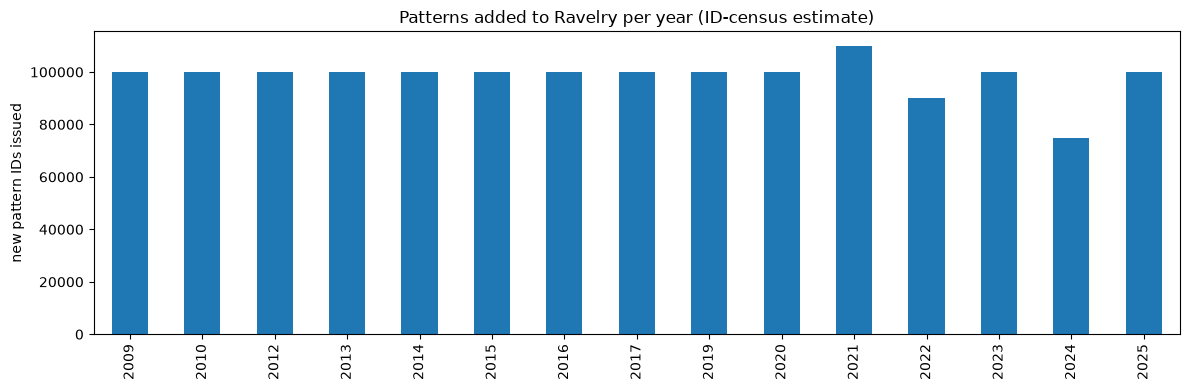

In [297]:
import json
id_map = json.loads((DATA / "manifests" / "id_year_map.json").read_text())
pts = sorted(map(tuple, id_map))
year_width: dict[int, int] = {}
for (id0, y0), (id1, y1) in zip(pts, pts[1:]):
    gap = id1 - id0
    if gap > 250_000:  # the 2023 ID re-basing hole — no patterns there
        continue
    year_width[y0] = year_width.get(y0, 0) + gap

census = pd.Series(year_width).sort_index()
fig, ax = plt.subplots(figsize=(12, 4))
census.plot(kind="bar", ax=ax)
ax.set_ylabel("new pattern IDs issued")
ax.set_title("Patterns added to Ravelry per year (ID-census estimate)")
plt.tight_layout()
census

## 1. The headline shape: fan distributions by cohort year
Log scale — the compression of the middle should be visible here
before any statistics. (This is the violin the research plan wanted.)

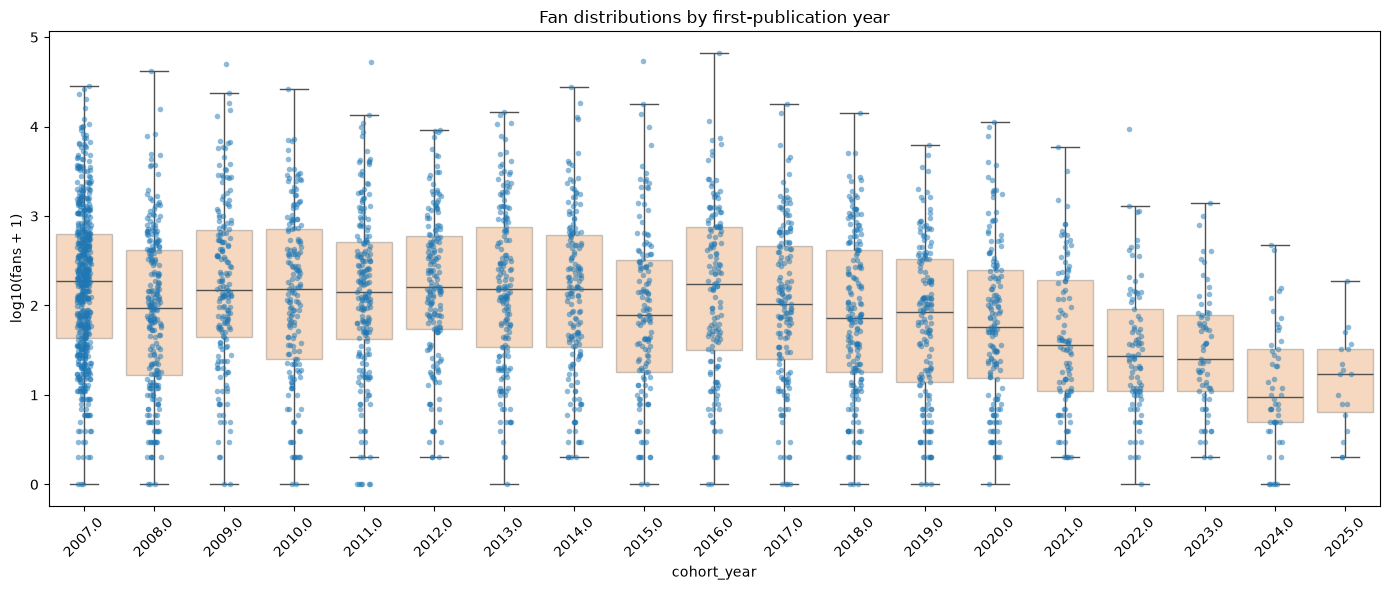

In [298]:
plot_df = df.dropna(subset=["cohort_year", "fan_count"]).copy()
plot_df["log_fans"] = np.log10(plot_df["fan_count"] + 1)

fig, ax = plt.subplots(figsize=(14, 6))
sns.stripplot(data=plot_df, x="cohort_year", y="log_fans",
              alpha=0.5, size=4, ax=ax)
sns.boxplot(data=plot_df, x="cohort_year", y="log_fans",
            showfliers=False, boxprops=dict(alpha=0.3), ax=ax)
ax.set_ylabel("log10(fans + 1)")
ax.set_title("Fan distributions by first-publication year")
plt.xticks(rotation=45)
plt.tight_layout()

## 2. Middle-band share — "the middle is falling out"
Share of each cohort with 500–5,000 fans (the livable middle).
Also floor (≥100 fans) and breakout (≥10k) rates.

In [299]:
by_year = df.dropna(subset=["cohort_year"]).groupby("cohort_year")["fan_count"]
summary = pd.DataFrame({
    "n": by_year.size(),
    "median": by_year.median(),
    "middle_band": by_year.apply(lambda f: ((f >= 500) & (f <= 5000)).mean()),
    "floor_100": by_year.apply(lambda f: (f >= 100).mean()),
    "breakout_10k": by_year.apply(lambda f: (f >= 10_000).mean()),
    "gini": by_year.apply(gini),
})
summary

,n,median,middle_band,floor_100,breakout_10k,gini
cohort_year,,,,,,
2007.0,568,185.0,0.255282,0.610915,0.014085,0.793226
2008.0,240,93.5,0.204167,0.483333,0.008333,0.842433
2009.0,175,149.0,0.257143,0.588571,0.028571,0.839766
2010.0,169,150.0,0.260355,0.568047,0.005917,0.781571
2011.0,200,139.5,0.220000,0.580000,0.015000,0.834225
2012.0,171,159.0,0.263158,0.625731,0.000000,0.746826
2013.0,169,152.0,0.260355,0.603550,0.023669,0.787674
2014.0,164,153.5,0.243902,0.573171,0.024390,0.820965
2015.0,139,77.0,0.143885,0.453237,0.021583,0.891571


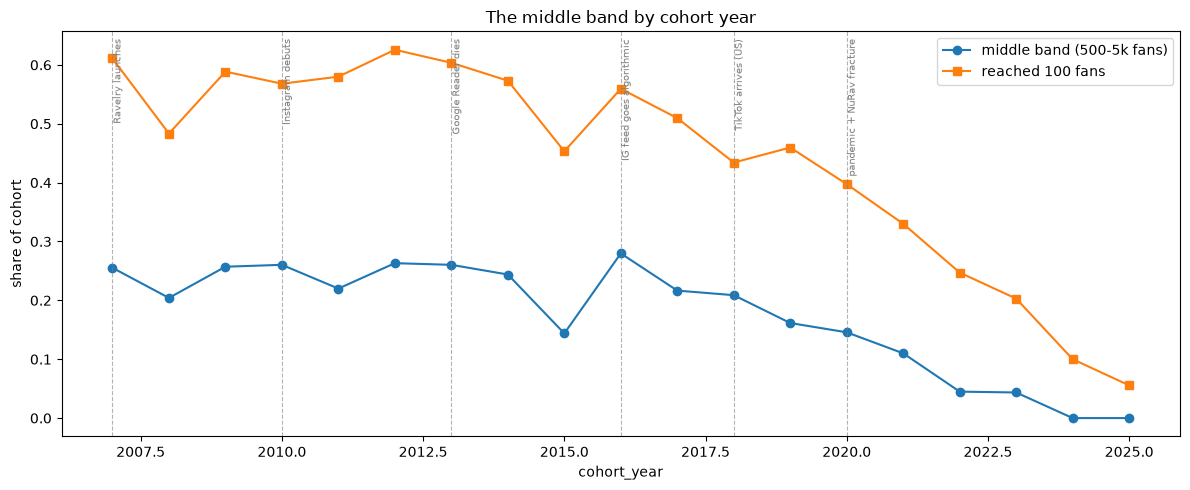

In [300]:
fig, ax = plt.subplots(figsize=(12, 5))
summary["middle_band"].plot(marker="o", ax=ax, label="middle band (500-5k fans)")
summary["floor_100"].plot(marker="s", ax=ax, label="reached 100 fans")
ax.set_ylabel("share of cohort")
ax.set_title("The middle band by cohort year")
ax.legend()
add_milestones(ax)
plt.tight_layout()

## 2c. Golden ages: when was the window open, and for how long?
"Open" = a cohort year whose entrants had a decent shot at finding
any audience: share reaching 100 fans >= 55%. Shaded spans are
consecutive open years — their widths measure each golden age.
(Print-era window predates the data; institutional entrants excluded.)

open spans: [(2007.0, 2014.0), (2016.0, 2016.0)]


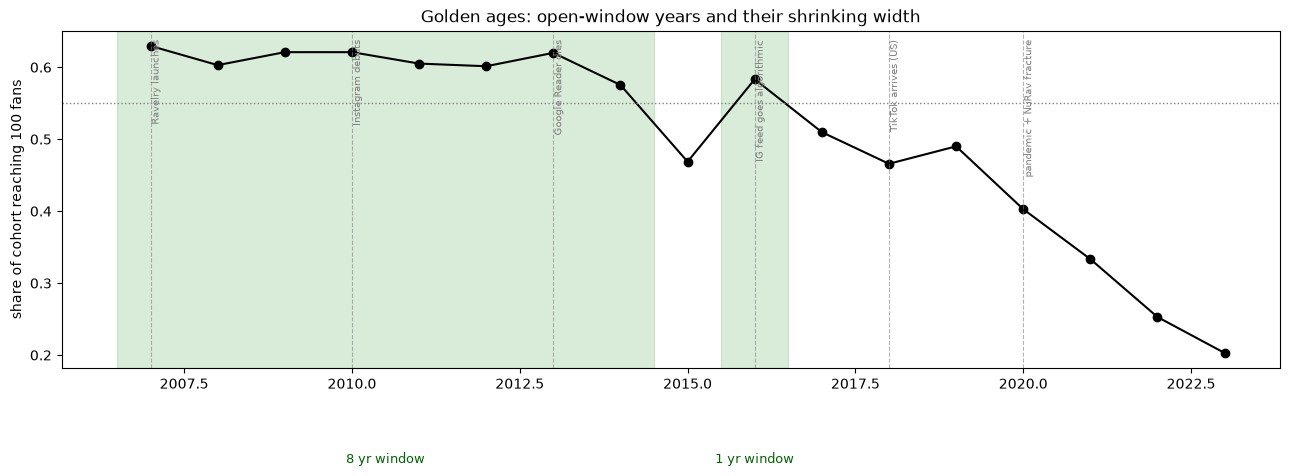

In [301]:
sp = df[(df["print_source_share"] <= 0.5)].dropna(
    subset=["cohort_year", "fan_count"])
fl = sp.groupby("cohort_year")["fan_count"].apply(
    lambda f: (f >= 100).mean())
fl = fl[(fl.index >= 2007) & (fl.index <= 2023)]

OPEN = 0.55
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(fl.index, fl.values, marker="o", color="black", lw=1.5)
ax.axhline(OPEN, ls=":", color="grey", lw=1)
# shade consecutive open runs and label their widths
run_start = None
spans = []
for year in list(fl.index) + [None]:
    is_open = year is not None and fl[year] >= OPEN
    if is_open and run_start is None:
        run_start = year
    elif not is_open and run_start is not None:
        spans.append((run_start, prev))
        run_start = None
    if year is not None:
        prev = year
for lo, hi in spans:
    ax.axvspan(lo - 0.5, hi + 0.5, alpha=0.15, color="green")
    ax.text((lo + hi) / 2, 0.05, f"{int(hi - lo + 1)} yr window",
            ha="center", fontsize=9, color="darkgreen")
add_milestones(ax)
ax.set_ylabel("share of cohort reaching 100 fans")
ax.set_title("Golden ages: open-window years and their shrinking width")
plt.tight_layout()
print("open spans:", spans)

## 2b. Concentration: who holds the cohort's attention?
The direct picture of "fewer designers, outsized influence."

Left: Lorenz curves — designers ranked poorest to richest along x,
cumulative share of the cohort's total fans along y. The diagonal is
perfect equality; the deeper the bow, the more the cohort's attention
belongs to its top few. This is the same chart used for wealth
inequality, which is the point.

Right: share of each cohort's total fans held by its top 10% and top
1 designer.

,top 10% of designers,top 1 designer
era,,
2007-12 (blog),0.711886,0.037602
2013-19 (early IG),0.729219,0.077666
2020-24 (algorithm),0.775124,0.090950


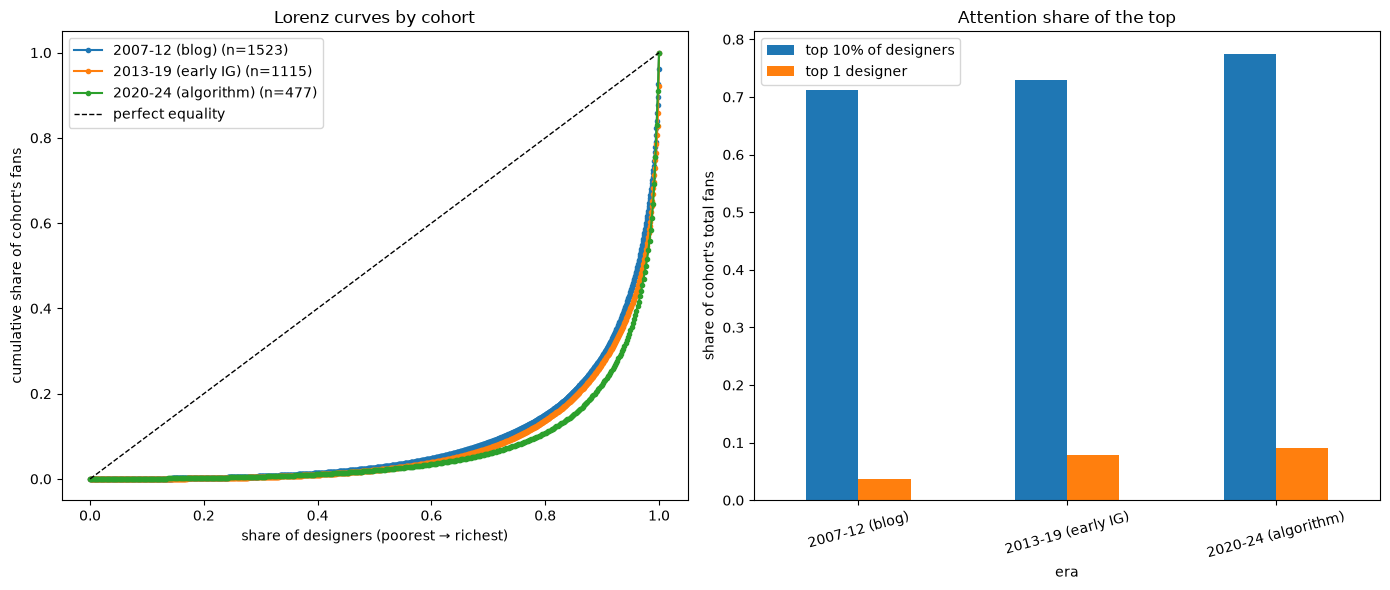

In [302]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for era in ERA_LABELS:
    fans = np.sort(df.loc[df["era"] == era, "fan_count"].dropna().values)
    if len(fans) < 5 or fans.sum() == 0:
        continue
    cum = np.insert(np.cumsum(fans) / fans.sum(), 0, 0)
    x = np.linspace(0, 1, len(cum))
    axes[0].plot(x, cum, marker=".", label=f"{era} (n={len(fans)})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="perfect equality")
axes[0].set_xlabel("share of designers (poorest → richest)")
axes[0].set_ylabel("cumulative share of cohort's fans")
axes[0].set_title("Lorenz curves by cohort")
axes[0].legend()

conc = []
for era in ERA_LABELS:
    fans = df.loc[df["era"] == era, "fan_count"].dropna().sort_values(
        ascending=False)
    if len(fans) < 5 or fans.sum() == 0:
        continue
    n10 = max(1, len(fans) // 10)
    conc.append({"era": era,
                 "top 10% of designers": fans.head(n10).sum() / fans.sum(),
                 "top 1 designer": fans.iloc[0] / fans.sum()})
conc_df = pd.DataFrame(conc).set_index("era")
conc_df.plot(kind="bar", ax=axes[1], rot=15)
axes[1].set_ylabel("share of cohort's total fans")
axes[1].set_title("Attention share of the top")
plt.tight_layout()
conc_df

## 3. Time-on-platform control: fans per year since first publication
The raw medians conflate cohort with account age; this is the
plan's normalization.

In [303]:
df["years_active"] = 2026 - df["cohort_year"]
df["fans_per_year"] = df["fan_count"] / df["years_active"].clip(lower=1)
df.groupby("cohort4", observed=True)[["fans_per_year", "fans_per_pattern",
                                      "fan_count"]].median()

,fans_per_year,fans_per_pattern,fan_count
cohort4,,,
print/institutional,6.315789,0.996124,103.0
2007-12 (blog),10.911765,2.508065,183.5
2013-19 (early IG),11.923077,2.000000,117.0
2020-24 (algorithm),8.000000,0.878505,32.0


## 3b. Fans per pattern by cohort year
The "audience earned per unit of output" measure — the ceiling story.
Median (solid) is the honest central line for heavy-tailed data; the
mean (dashed) is shown for contrast — where they diverge, an outlier
is doing the talking. Shaded band = 25th–75th percentile.

,count,median,mean
cohort_year,,,
2007.0,568,1.43,4.68
2008.0,240,1.39,4.02
2009.0,175,2.27,7.99
2010.0,169,1.86,6.02
2011.0,200,2.19,7.62
2012.0,171,2.05,4.15
2013.0,169,2.25,6.23
2014.0,164,1.91,5.48
2015.0,139,1.46,7.37


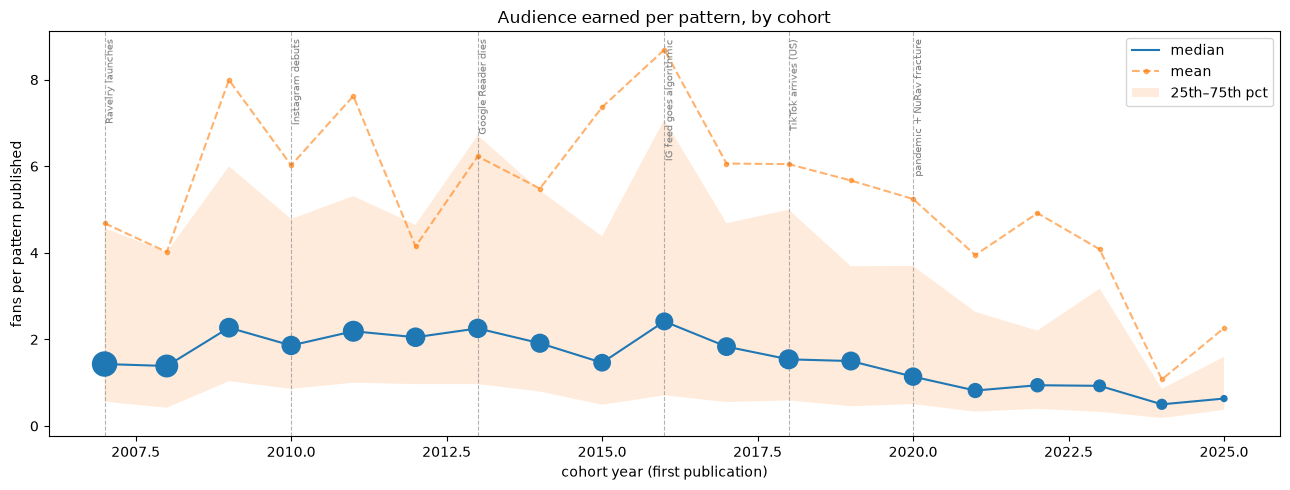

In [304]:
fpp = df.dropna(subset=["cohort_year", "fans_per_pattern"])
by_year_fpp = fpp.groupby("cohort_year")["fans_per_pattern"]

fig, ax = plt.subplots(figsize=(13, 5))
med = by_year_fpp.median()
ns = by_year_fpp.size()
ax.plot(med.index, med.values, lw=1.5, label="median")
# marker area tracks sample size: big dots are trustworthy, small
# dots are gossip
ax.scatter(med.index, med.values, s=ns.clip(upper=300), zorder=3)
ax.plot(by_year_fpp.mean().index, by_year_fpp.mean().values,
        linestyle="--", marker=".", alpha=0.6, label="mean")
ax.fill_between(med.index, by_year_fpp.quantile(0.25).values,
                by_year_fpp.quantile(0.75).values, alpha=0.15,
                label="25th–75th pct")
ax.set_xlabel("cohort year (first publication)")
ax.set_ylabel("fans per pattern published")
ax.set_title("Audience earned per pattern, by cohort")
ax.legend()
add_milestones(ax)
plt.tight_layout()
by_year_fpp.agg(["count", "median", "mean"]).round(2)

## 4. H7 — the crochet lag
Same shapes, split by craft. Crochet-majority designers should show
a later, still-open window.

In [305]:
df["craft"] = np.where(df["crochet_share"] > 0.5, "crochet", "knitting")
df.groupby(["era", "craft"], observed=True).agg(
    n=("fan_count", "size"),
    median_fans=("fan_count", "median"),
    median_fpy=("fans_per_year", "median"),
    gini=("fan_count", gini),
)

n  median_fans  median_fpy      gini
era                 craft                                            
2007-12 (blog)      crochet    464        147.0    8.753759  0.727710
                    knitting  1059        151.0    8.947368  0.827570
2013-19 (early IG)  crochet    559        117.0   12.444444  0.740616
                    knitting   556         92.5    9.437500  0.860093
2020-24 (algorithm) crochet    286         25.5    6.300000  0.783249
                    knitting   191         40.0    8.833333  0.857412

## 4b. Top designers per cohort year
Who from each entry class holds the most attention TODAY. (Fans are
lifetime totals with no timestamps — this is the class reunion, not
the yearbook. Historical accumulation lives in the Wayback panels.)

In [306]:
top = (df.dropna(subset=["cohort_year", "fan_count"])
         .sort_values("fan_count", ascending=False)
         .groupby("cohort_year")
         .head(3)
         .sort_values(["cohort_year", "fan_count"],
                      ascending=[True, False]))
top[["cohort_year", "designer_name", "fan_count", "n_patterns",
     "fans_per_pattern", "instagram"]].reset_index(drop=True)

,cohort_year,designer_name,fan_count,n_patterns,fans_per_pattern,instagram
0,2007.0,Purl Soho,28162,883,31.893545,http://instagram.com/purlsoho
1,2007.0,Claire Garland,26025,443,58.747178,http://instagram.com/dotpebbles_knits
2,2007.0,Jared Flood,22981,240,95.754167,http://instagram.com/brooklyntweed
3,2008.0,Joji Locatelli,42173,354,119.132768,http://instagram.com/jojilocat
4,2008.0,Frankie Brown,15702,614,25.573290,NaN
5,2008.0,Tamara Kelly,8356,749,11.156208,http://instagram.com/mooglyblog
6,2009.0,Stephen West,49508,663,74.672700,http://instagram.com/westknits
7,2009.0,Veera Välimäki,24045,435,55.275862,http://instagram.com/veerarain
8,2009.0,Heidi Kirrmaier,18307,113,162.008850,http://instagram.com/heidikdesigns
9,2010.0,ANKESTRiCK,26042,141,184.695035,http://instagram.com/ankestrick


## 4c. Cohort winners: career spans
Each cohort year's top designer as a horizontal bar from first to
last publication, labeled with current fans. Dashed lines mark the
hypothesized inflection points (Google Reader death 2013, Instagram
algorithmic feed 2016). Fans have no timestamps, so this shows how
long each winner KEPT PUBLISHING, not when the fans arrived — that
needs the Wayback panels / per-pattern hit curves.

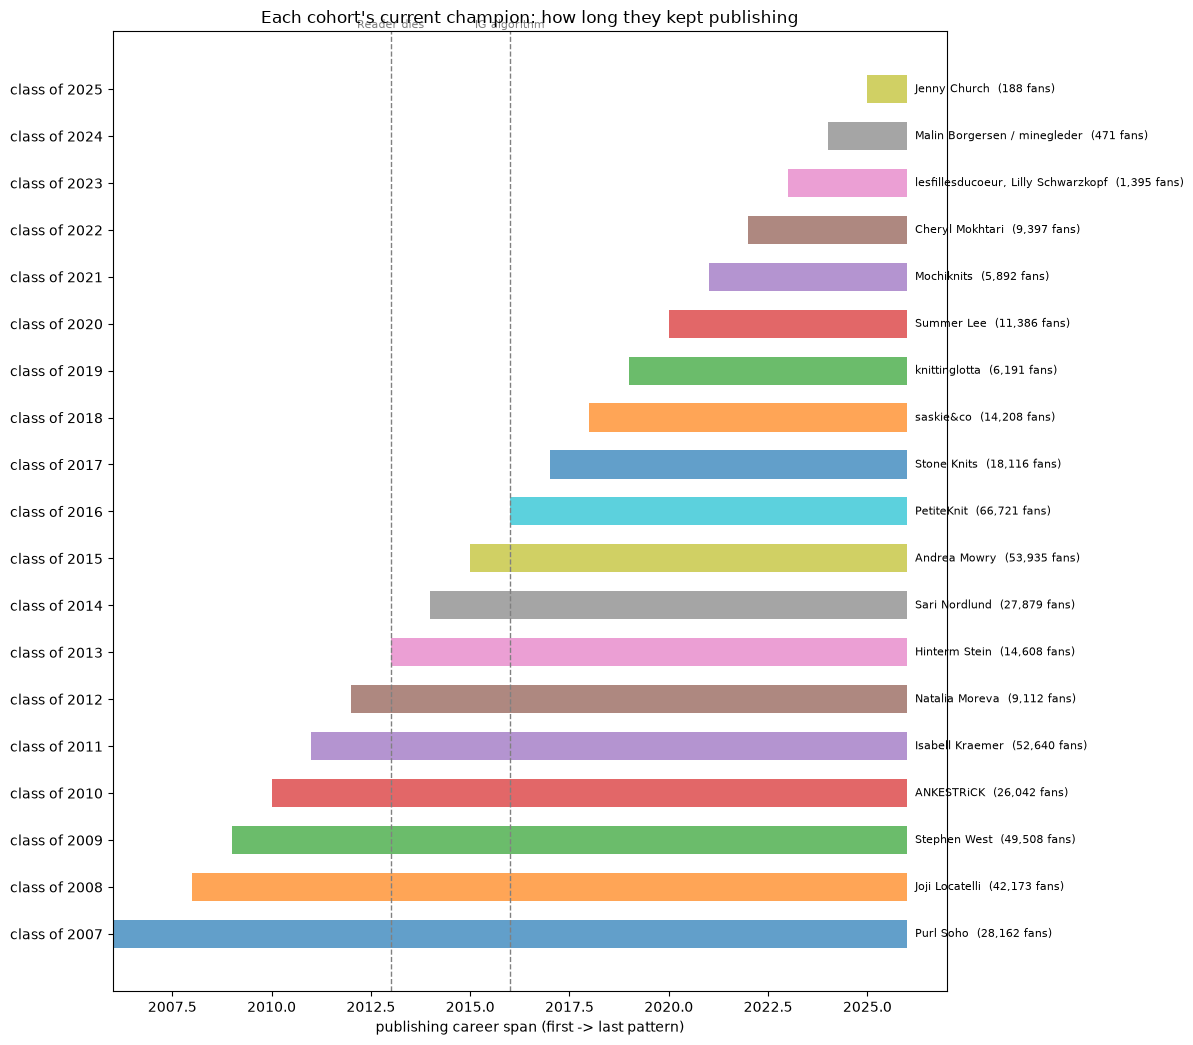

In [307]:
champs = (df.dropna(subset=["cohort_year", "fan_count"])
            .sort_values("fan_count", ascending=False)
            .groupby("cohort_year").head(1)
            .sort_values("cohort_year"))
champs["first_y"] = pd.to_numeric(champs["first_pub_anywhere"].str[:4],
                                  errors="coerce")
champs["last_y"] = pd.to_numeric(champs["last_pattern_published"].str[:4],
                                 errors="coerce")

fig, ax = plt.subplots(figsize=(12, 0.45 * len(champs) + 2))
for i, (_, c) in enumerate(champs.iterrows()):
    if pd.isna(c["first_y"]) or pd.isna(c["last_y"]):
        continue
    ax.barh(i, max(c["last_y"] - c["first_y"], 0.3), left=c["first_y"],
            height=0.6, alpha=0.7)
    ax.text(c["last_y"] + 0.2, i,
            f"{c['designer_name']}  ({int(c['fan_count']):,} fans)",
            va="center", fontsize=8)
for x, label in [(2013, "Reader dies"), (2016, "IG algorithm")]:
    ax.axvline(x, ls="--", lw=1, color="grey")
    ax.text(x, len(champs) + 0.3, label, fontsize=8, ha="center",
            color="grey")
ax.set_yticks(range(len(champs)))
ax.set_yticklabels([f"class of {int(y)}" for y in champs["cohort_year"]])
ax.set_xlabel("publishing career span (first -> last pattern)")
ax.set_title("Each cohort's current champion: how long they kept publishing")
plt.tight_layout()

## 5. The institutional route — print share by cohort

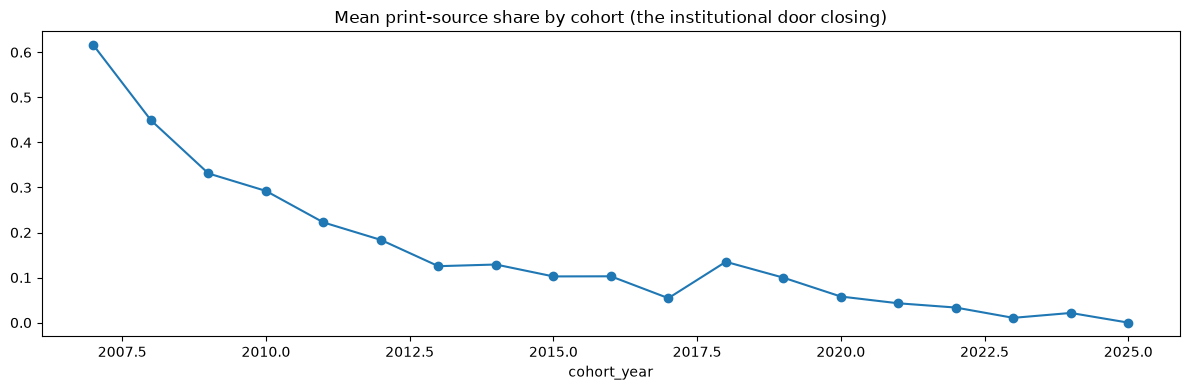

In [308]:
fig, ax = plt.subplots(figsize=(12, 4))
df.dropna(subset=["cohort_year"]).groupby("cohort_year")[
    "print_source_share"].mean().plot(marker="o", ax=ax)
ax.set_title("Mean print-source share by cohort (the institutional door closing)")
plt.tight_layout()

## 6. Persistence — last publication recency by cohort
The viability proxy: still publishing?

In [309]:
df["last_pub_year"] = pd.to_numeric(df["last_pattern_published"].str[:4],
                                    errors="coerce")
df["active_recent"] = df["last_pub_year"] >= 2024
df.groupby("era", observed=True)["active_recent"].mean()

era
2007-12 (blog)         0.323047
2013-19 (early IG)     0.504036
2020-24 (algorithm)    0.767296
Name: active_recent, dtype: float64

## 7. Anchors vs. the field
Where do the named designers sit against the sampled distribution?

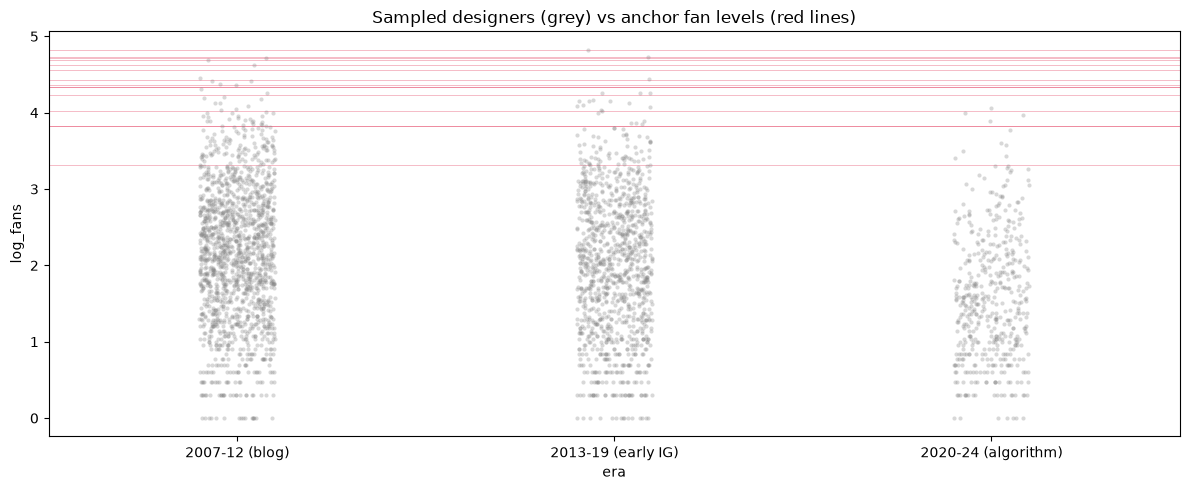

In [310]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.stripplot(data=plot_df, x="era", y="log_fans", alpha=0.3, size=3,
              color="grey", ax=ax)
for _, a in anchors.iterrows():
    if pd.notna(a.get("fan_count")):
        ax.axhline(np.log10(a["fan_count"] + 1), lw=0.5, alpha=0.4, color="crimson")
ax.set_title("Sampled designers (grey) vs anchor fan levels (red lines)")
plt.tight_layout()